# Toronto Island Ferry Ticket Counts: Time Series Analysis Showcase

## 1. Introduction
This notebook demonstrates a complete time series analysis workflow using the Toronto Island Ferry Ticket Counts dataset. The goal is to showcase skills in:
- **Data Acquisition**: Fetching data from an API.
- **Data Preprocessing**: Cleaning and resampling time series data.
- **Exploratory Data Analysis (EDA)**: Visualizing trends and seasonality.
- **Time Series Decomposition**: Breaking down the series into trend, seasonal, and residual components.
- **Forecasting**: Building a predictive model using Holt-Winters Exponential Smoothing.

**Dataset Source**: [Toronto Open Data - Toronto Island Ferry Ticket Counts](https://open.toronto.ca/dataset/toronto-island-ferry-ticket-counts/)

## 2. Data Acquisition

In [1]:
import os
import sys

# Add parent directory to path to import utils
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

from utils.download_data import download_data

# Define download parameters
params = { "id": "toronto-island-ferry-ticket-counts"}
download_path = os.path.join(os.pardir, "data", "toronto-island-ferry-ticket-counts.csv")

# Ensure data directory exists
os.makedirs(os.path.dirname(download_path), exist_ok=True)

# Download the latest data
print("Downloading latest data...")
download_data(params, download_path)
print(f"Data saved to {download_path}")

Data saved to ../data/toronto-island-ferry-ticket-counts.csv


## 3. Data Preprocessing

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style for better aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
df = pd.read_csv(download_path)

# Convert 'Timestamp' to datetime objects
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Set Timestamp as index
df.set_index('Timestamp', inplace=True)

# Sort the index to ensure chronological order
df.sort_index(inplace=True)

# Display basic info
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 259952 entries, 2015-05-01 13:30:00 to 2025-11-25 19:30:00
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   _id               259952 non-null  int64
 1   Redemption Count  259952 non-null  int64
 2   Sales Count       259952 non-null  int64
dtypes: int64(3)
memory usage: 7.9 MB
None


,_id,Redemption Count,Sales Count
Timestamp,,,
2015-05-01 13:30:00,259952,0,1
2015-05-01 15:15:00,259951,0,2
2015-05-01 15:45:00,259950,0,1
2015-05-01 16:00:00,259949,1,0
2015-05-04 16:00:00,259948,0,2


### Resampling
The raw data is in 15-minute intervals, which can be noisy. We will resample the data to a **Weekly** frequency to smooth out daily fluctuations and focus on broader seasonal trends.

In [3]:
# Resample to Weekly frequency, summing the counts
df_weekly = df[['Sales Count', 'Redemption Count']].resample('W').sum()

# Rename columns for convenience
df_weekly.rename(columns={'Sales Count': 'Sales', 'Redemption Count': 'Redemptions'}, inplace=True)

df_weekly.head()

,Sales,Redemptions
Timestamp,,
2015-05-03,4,1
2015-05-10,17241,13606
2015-05-17,25334,18006
2015-05-24,36152,30138
2015-05-31,18554,15919


## 4. Exploratory Data Analysis (EDA)

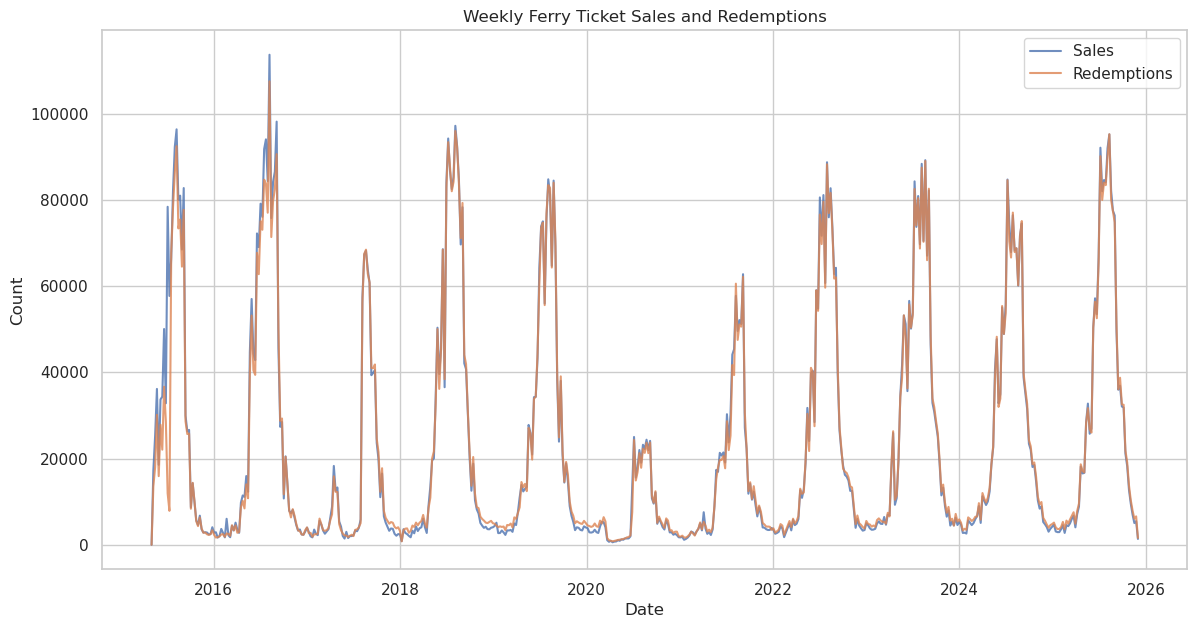

In [4]:
# Plot Sales and Redemptions over time
plt.figure(figsize=(14, 7))
plt.plot(df_weekly.index, df_weekly['Sales'], label='Sales', alpha=0.8)
plt.plot(df_weekly.index, df_weekly['Redemptions'], label='Redemptions', alpha=0.8)
plt.title('Weekly Ferry Ticket Sales and Redemptions')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.show()

### Seasonality Analysis
Let's look at the average sales by month to confirm the expected summer peak.

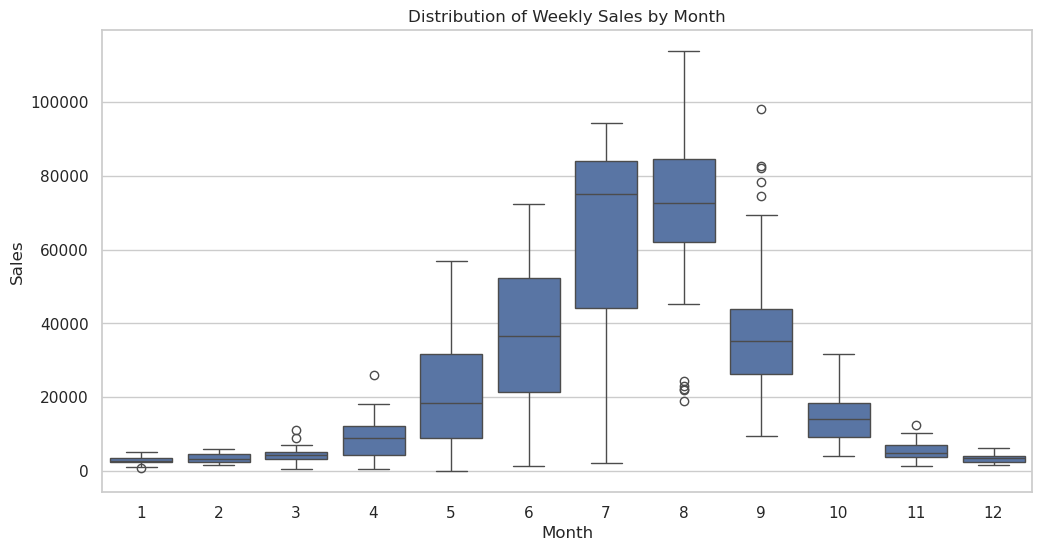

In [5]:
# Create a copy for seasonality analysis
df_seasonal = df_weekly.copy()
df_seasonal['Month'] = df_seasonal.index.month
df_seasonal['Year'] = df_seasonal.index.year

# Boxplot of Sales by Month
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Sales', data=df_seasonal)
plt.title('Distribution of Weekly Sales by Month')
plt.show()

### Time Series Decomposition
We decompose the 'Sales' time series into **Trend**, **Seasonality**, and **Residuals** to better understand its components.

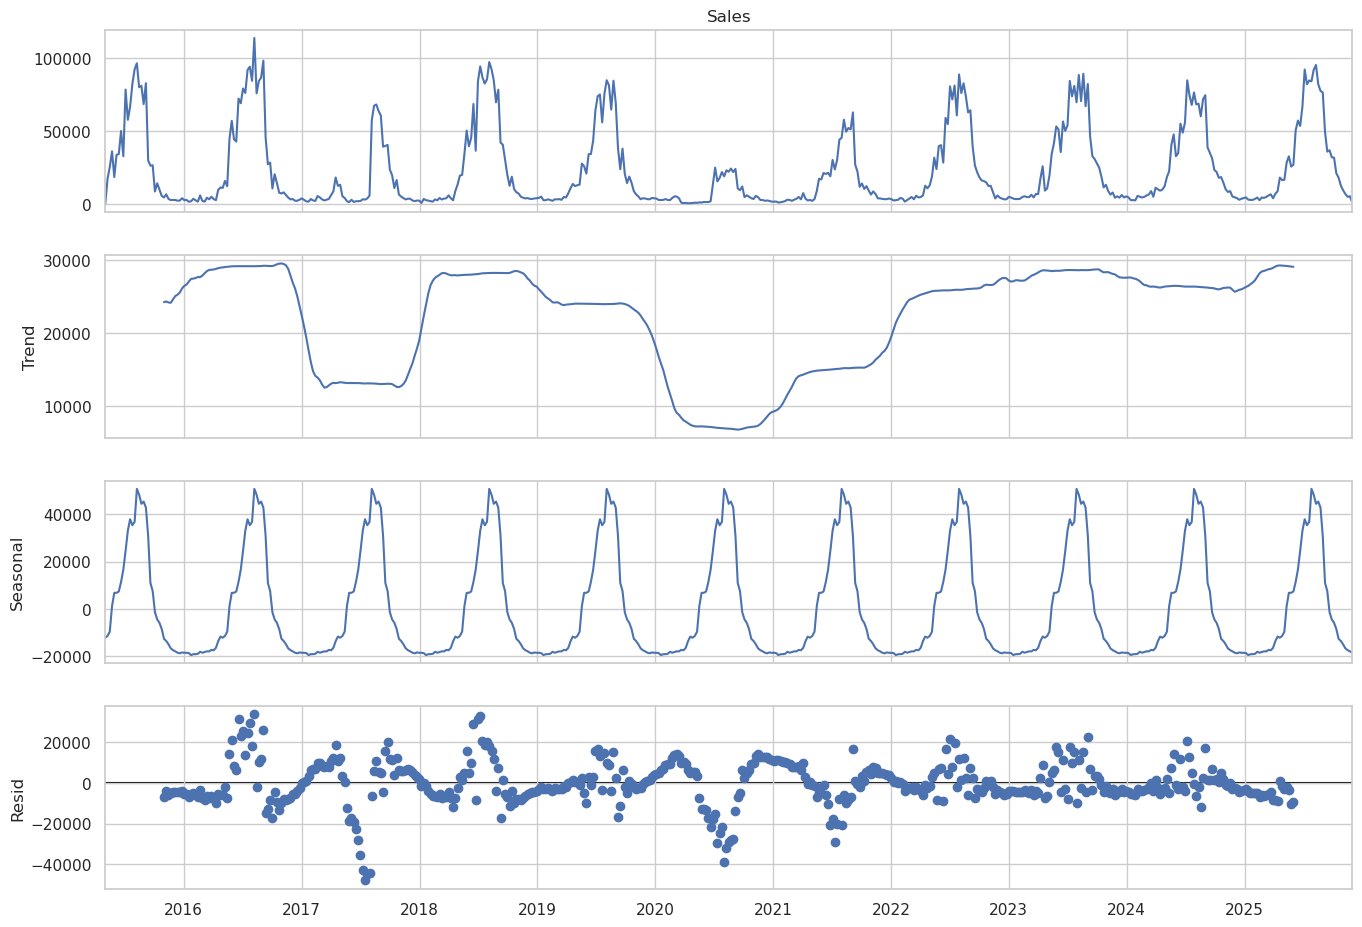

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the Sales data
# Using additive model as the amplitude of seasonality seems relatively constant over time (mostly)
decomposition = seasonal_decompose(df_weekly['Sales'], model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

## 5. Forecasting Showcase
We will use the **Holt-Winters Exponential Smoothing** method, which is suitable for data with trend and seasonality.

In [7]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split data into Train and Test sets
# Use the last year (52 weeks) for testing
train_size = len(df_weekly) - 52
train_data = df_weekly['Sales'][:train_size]
test_data = df_weekly['Sales'][train_size:]

print(f"Training samples: {len(train_data)}, Test samples: {len(test_data)}")

# Fit the Holt-Winters model
# 'mul' for multiplicative seasonality can be tried if amplitude varies, but 'add' is often robust
model = ExponentialSmoothing(
    train_data,
    seasonal_periods=52,
    trend='add',
    seasonal='add',
    use_boxcox=True,
    initialization_method="estimated"
).fit()

# Forecast
forecast = model.forecast(len(test_data))

# Evaluate
mae = mean_absolute_error(test_data, forecast)
rmse = np.sqrt(mean_squared_error(test_data, forecast))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Training samples: 501, Test samples: 52
Mean Absolute Error (MAE): 9877.33
Root Mean Squared Error (RMSE): 17431.41


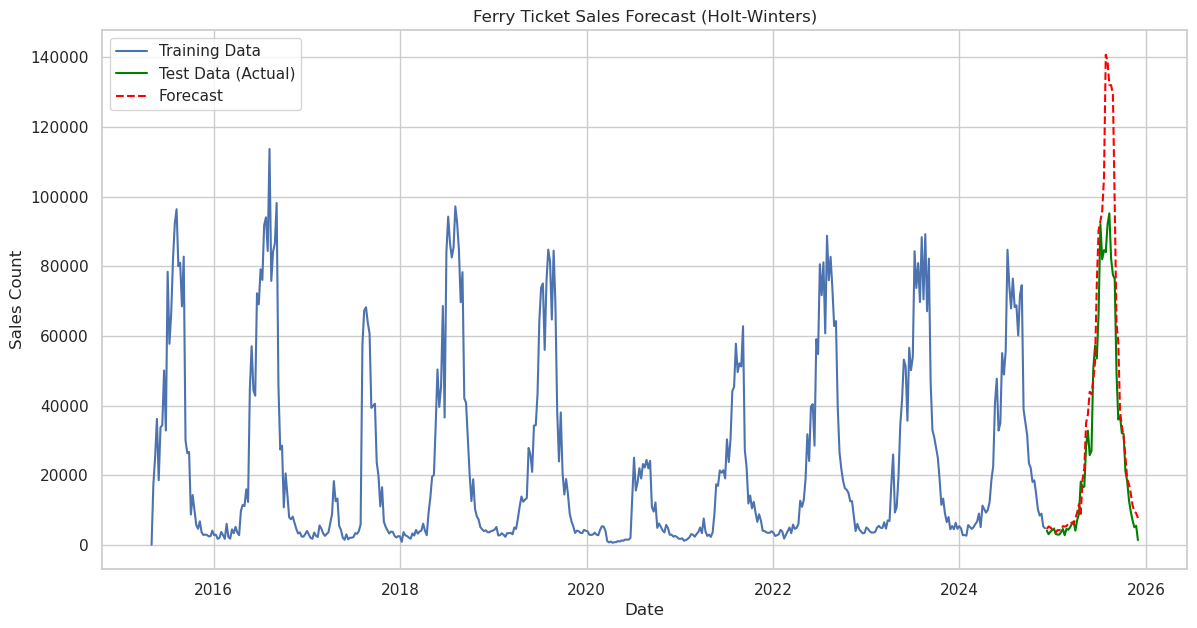

In [8]:
# Visualize Forecast vs Actual
plt.figure(figsize=(14, 7))
plt.plot(train_data.index, train_data, label='Training Data')
plt.plot(test_data.index, test_data, label='Test Data (Actual)', color='green')
plt.plot(test_data.index, forecast, label='Forecast', color='red', linestyle='--')
plt.title('Ferry Ticket Sales Forecast (Holt-Winters)')
plt.xlabel('Date')
plt.ylabel('Sales Count')
plt.legend()
plt.show()

## 6. Conclusion
This notebook demonstrated a full cycle of time series analysis:
1.  **Data was successfully fetched** from the Toronto Open Data API.
2.  **Preprocessing** converted granular 15-minute data into a cleaner weekly format.
3.  **EDA** confirmed strong annual seasonality with peaks in summer months.
4.  **Decomposition** isolated the underlying trend and seasonal patterns.
5.  **Forecasting** with Holt-Winters provided a baseline for predicting future ticket sales, which can aid in resource planning and staffing for the ferry service.